# Central Bank & Government — Transaction Diagrams

Defines starting balance sheets for a Central Bank and a Government, then uses `BalanceSheetTransactions` to draw the starting position and each subsequent transaction. Every figure is collected on the instance and bundled into a single HTML report at the end.

In [31]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

from balance_butterfly import BalanceSheetTransactions, RawButterflyData

## Starting balance sheets

In [32]:
CB: RawButterflyData = {
    'assets': {
        'Government bonds':            600,
        'Foreign reserves':           1200,
        'Other assets':                100,
    },
    'liabilities': {
        'Currency in circulation':     500,
        'Working capital currency':    200,
        'Investment capital currency': 200,
        'Bank reserves':               200,
        'GFECRA':                     [500, 'gold'],
    },
    'equity': {
        'Capital & reserves': 100,
    },
}

GOVT: RawButterflyData = {
    'assets': {
        'Domestic Bank':               200,
        'Working capital currency':    200,
        'Investment capital currency': 200,
        'GFECRA':                     [500, 'gold'],
    },
    'liabilities': {
        'Government bonds':           600,
        'Government bonds currency':  600,
        'Short-term bills':           100,
    },
    'equity': {
        'Capital & reserves': 100,
    },
}

## Wrap both sheets in a `BalanceSheetTransactions` instance

Each balance sheet gets a short identifier (`'C'`, `'G'`); the same identifier keys per-transaction change dicts. `ncols=2` keeps two panels per row by default.

In [33]:
bs = BalanceSheetTransactions(
    sheets={'C': CB, 'G': GOVT},
    titles={'C': 'Central Bank', 'G': 'Government'},
    ncols=2,
)

## Starting position

`draw_start` renders the starting balance sheets with no changes overlaid.

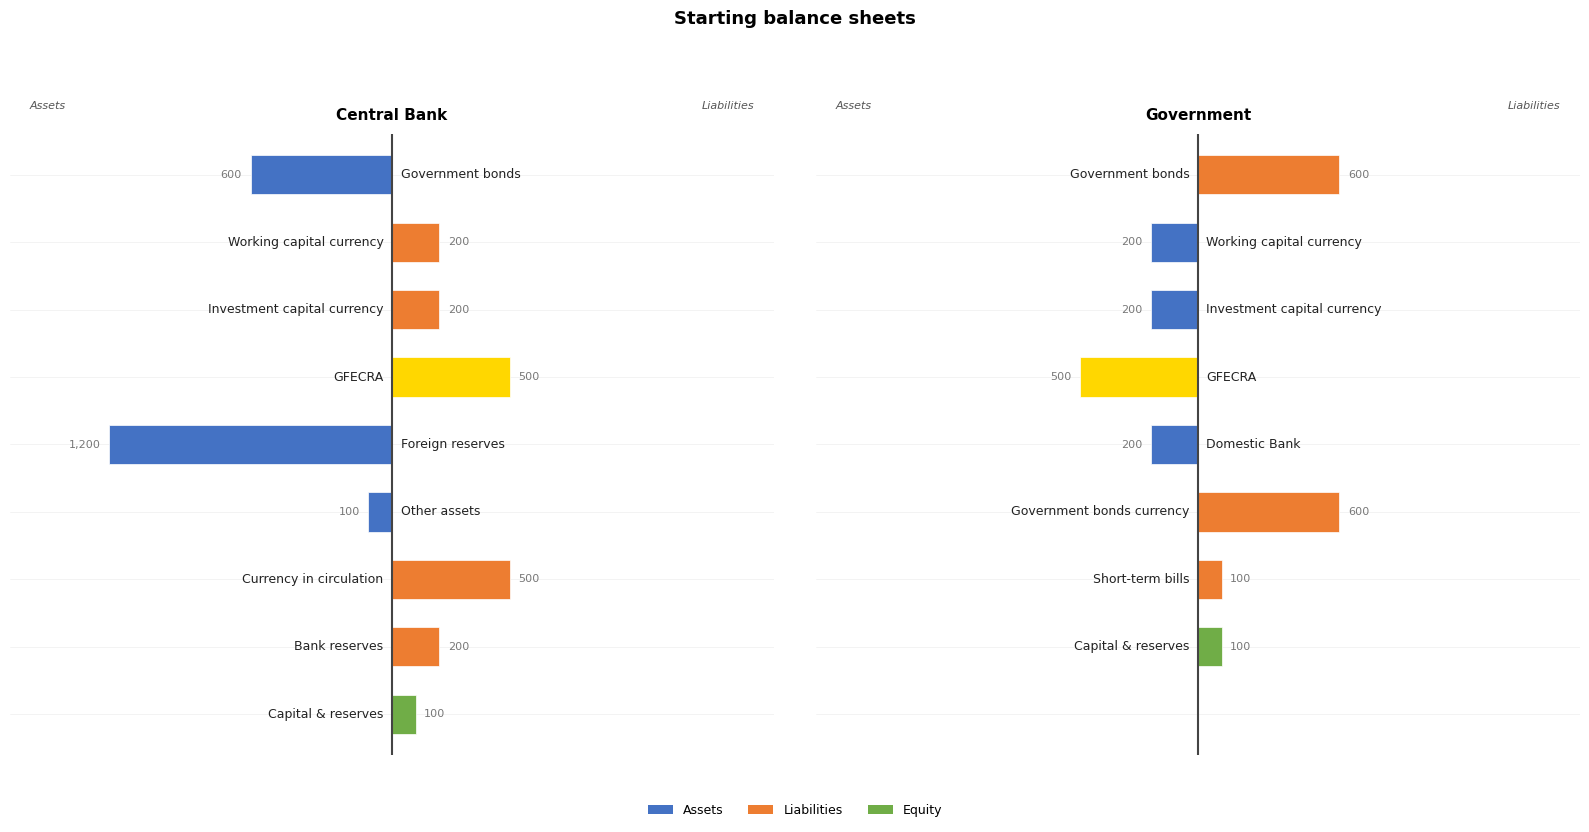

In [34]:
bs.draw_start(title='Starting balance sheets',file_format='png')

---
## Currency reserves financed by the Government

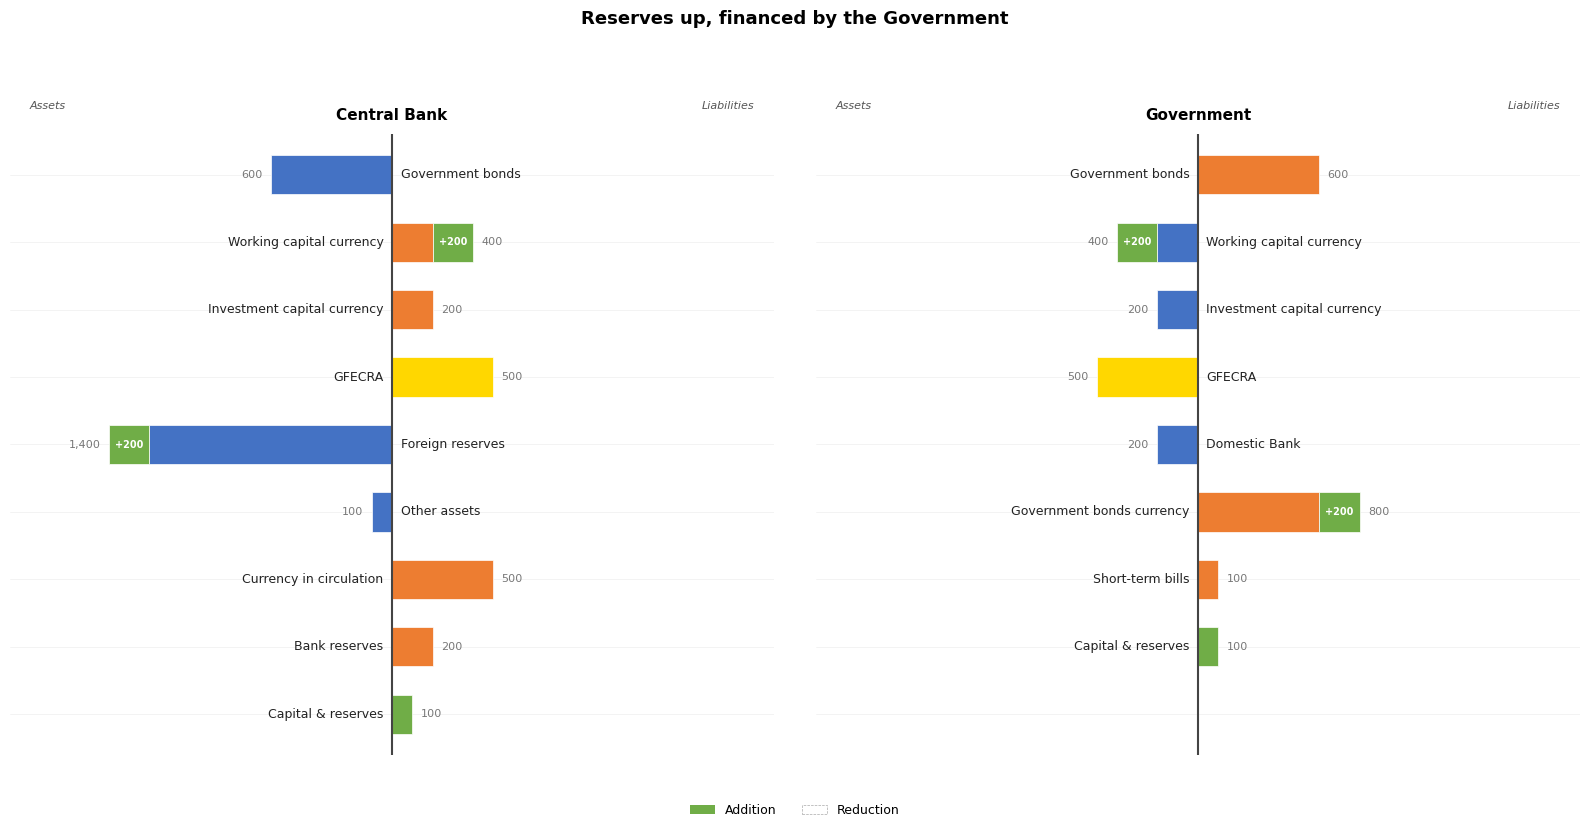

In [35]:
bs.draw_transaction(
    {
        'C': {'assets':      {'Foreign reserves':           +200},
              'liabilities': {'Working capital currency':   +200}},
        'G': {'assets':      {'Working capital currency':   +200},
              'liabilities': {'Government bonds currency':  +200}},
    },
    title='Reserves up, financed by the Government',file_format='png'
)

---
## Gold price up

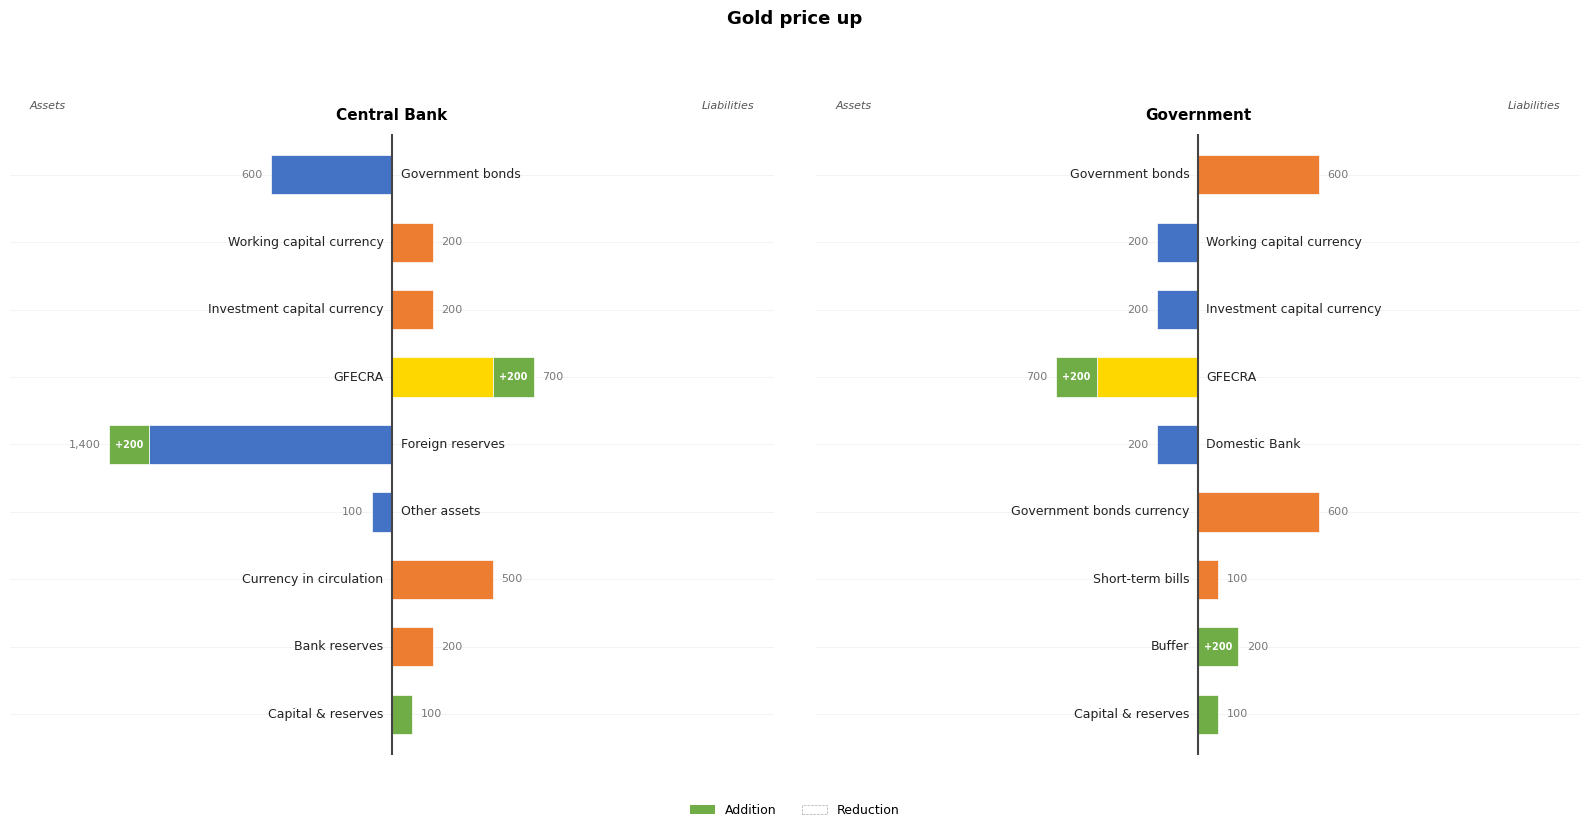

In [36]:
bs.draw_transaction(
    {
        'C': {'assets':      {'Foreign reserves': +200},
              'liabilities': {'GFECRA':           +200}},
        'G': {'assets':      {'GFECRA':           +200},
              'liabilities': {'Buffer':           +200}},
    },
    title='Gold price up',file_format='png'
)

---
## Central bank lends directly to the Government

CB grants a direct loan; Govt deposit rises on both sheets.

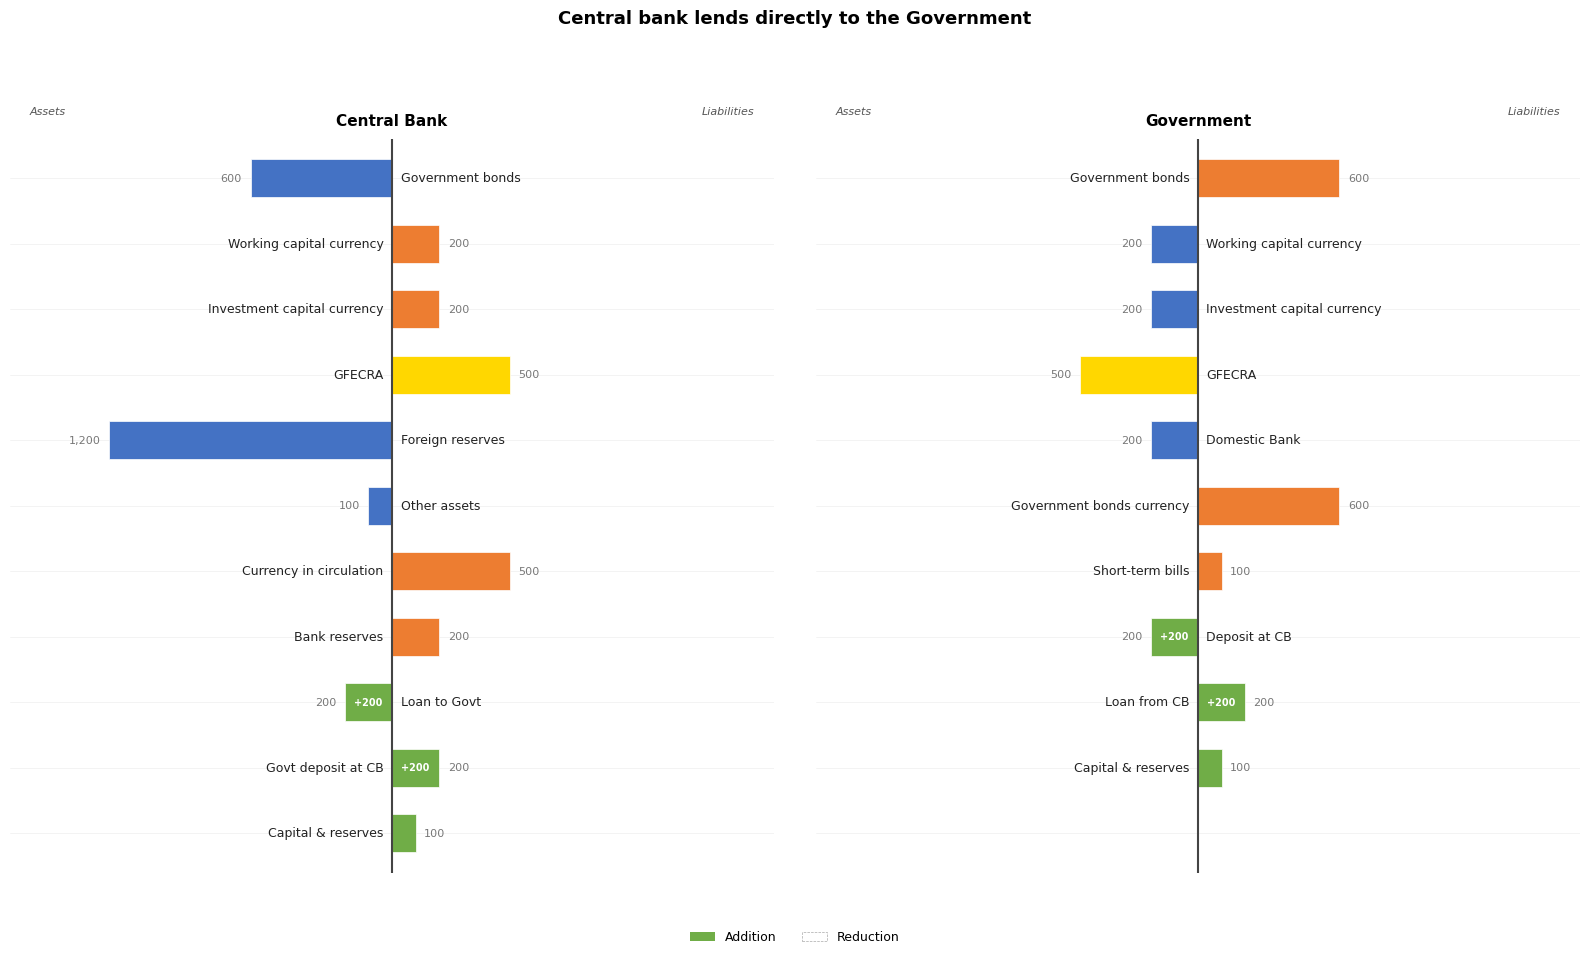

In [37]:
bs.draw_transaction(
    {
        'C': {'assets':      {'Loan to Govt':       +200},
              'liabilities': {'Govt deposit at CB': +200}},
        'G': {'assets':      {'Deposit at CB': +200},
              'liabilities': {'Loan from CB':  +200}},
    },
    title='Central bank lends directly to the Government',file_format='png',
)

---
## Government issues bonds, CB buys at auction

New bonds appear on both sides; Govt deposit rises.

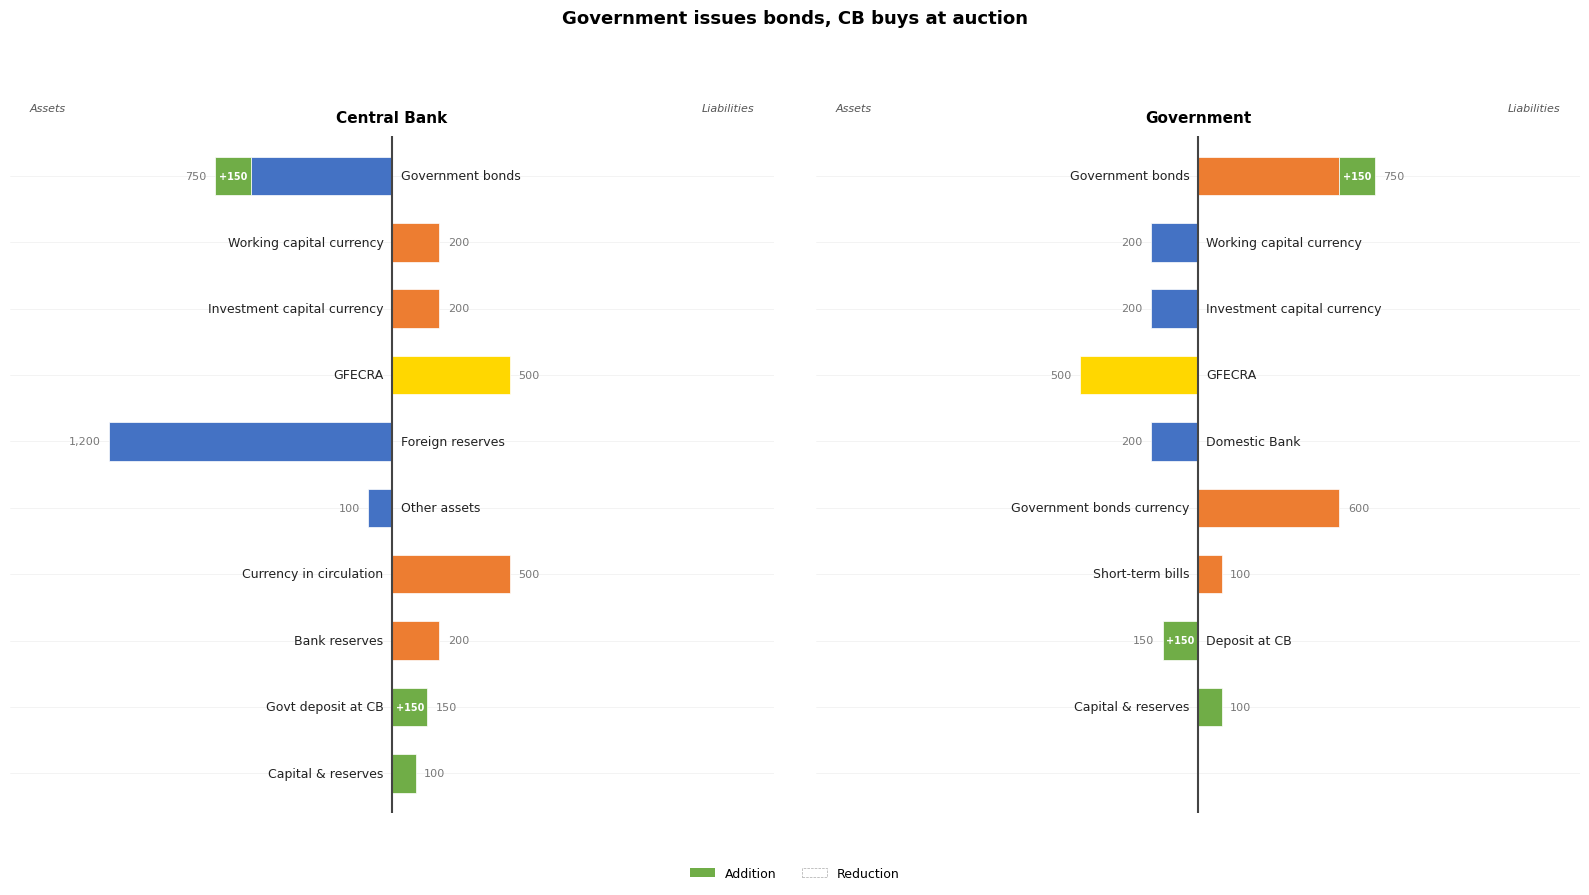

In [38]:
bs.draw_transaction(
    {
        'C': {'assets':      {'Government bonds':   +150},
              'liabilities': {'Govt deposit at CB': +150}},
        'G': {'assets':      {'Deposit at CB':    +150},
              'liabilities': {'Government bonds': +150}},
    },
    title='Government issues bonds, CB buys at auction',file_format='png',
)

---
## Save all charts to a single HTML report

`save_report` bundles every figure on the instance (starting sheets + every transaction drawn so far) into one self-contained HTML file under `html/`, with a table of contents and 'Back to top' links.

In [39]:
bs.save_report(
    name='cb_govt_transactions',
    page_title='Central bank & government transactions',
    browser=False,
)

WindowsPath('html/cb_govt_transactions.html')